# HBI&nbsp;03 — The likelihood, the MAP fit, and the MC band

**What this notebook does (in one breath):** **NB2** built the *forward kernel*
$A$ — the operator that maps a true CDDF $f(N)$ onto the rate of *measured*
detections. **Here we use it.** We open the **rate-form marked-Poisson
likelihood** that the kernel feeds, the **MAP deconvolution** that inverts it,
and the **Monte-Carlo band** that puts a statistical error on the answer — and
we read out the headline $dN/dX$ and $\Omega_{\rm HI}$ on the **real 2LPT-0 mock
catalog**.

```
  NB2:  forward kernel  A   (true f(N)  ->  measured-detection rate)
   │
   ▼  THIS NOTEBOOK
  marked-Poisson logL(f | catalog)     <- cell 3
   │
   ▼  MAP deconvolution (multi-start L-BFGS-B, smoothness prior)
  f_MAP  -> dN/dX, Omega at 20.0 / 20.3 / 20.6     <- cell 6
   │
   ▼  correlated Monte-Carlo
  statistical band around the MAP point            <- cell 8
```

**The reduce-only discipline.** The 1.7 GB forward kernel and the full MAP solve
ran *once*, at scale, on GreatLakes. This notebook does **not** re-run them.
Instead it **loads the cached results** (committed mock fixtures) and *reduces*
them to figures and integrated numbers. Every printed number is computed here
from the loaded arrays — nothing is typed in — but the heavy inference is shown
as a **command**, not executed. For a *live, runnable* MAP solve, **NB1** runs
the production solver `_solve_one_lambda` on a small synthetic problem in
seconds; this notebook is its real-data counterpart.

> **MOCK only.** Every number below is from the 2LPT-0 London-style mock. No real
> DESI/LOA spectra or values appear in this notebook.

> Companion notebooks: **NB1** — synthetic end-to-end closure (live solve);
> **NB2** — the real forward kernel; **NB4** — validation ($R_0$, null-field, SBC,
> cross-mock, the $\alpha=1/R_0$ honesty).

---

📄 **Paper-draft correspondence**: this notebook ↔ **Method** §§*Rate-form marked-Poisson likelihood*, *False-positive subtraction*, *MAP inference*, *Monte-Carlo uncertainty band*; **Validation** §(3) *Completeness & purity*; **Results** §*Literature consistency*.


In [1]:
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
for _v in ("OMP_NUM_THREADS","OPENBLAS_NUM_THREADS","MKL_NUM_THREADS","NUMEXPR_NUM_THREADS"):
    os.environ[_v] = "1"
import sys
from pathlib import Path
_root = next((p for p in (Path.cwd(), *Path.cwd().parents)
              if (p / "CDDF_analysis" / "hbi" / "cddf_catalog_hbi.py").exists()), None)
assert _root is not None, "repo root not found"
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
DATA = _root / "CDDF_analysis" / "hbi" / "tutorial_data"
# Inputs resolve via tutorial_fixture(): the committed mock fixture by default,
# or a fresh $CDDF_STORE leaf if you ran `python -m pipeline.run_pipeline`.
from CDDF_analysis.hbi.tutorial_data.fixtures import tutorial_fixture
import numpy as np
from CDDF_analysis.hbi import cddf_catalog_hbi as H
import matplotlib.pyplot as plt
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass
print("env ready | numpy", np.__version__, "| fixtures:", DATA.is_dir())

env ready | numpy 2.4.4 | fixtures: True


## The estimand: a rate-form marked-Poisson likelihood

The detection catalog is one realization of an inhomogeneous (marked) Poisson
process over the detection plane. Two **independent, superposed** Poisson
processes generate it: genuine absorbers (*real*) and forest false positives
(*FP*). Independent superposed Poisson processes simply **add their rates** —
there is **no cross term**. Writing $f$ for the binned CDDF heights we infer, the
log-likelihood is

$$
\log L
= -\bigl(\mu_{\rm det} + \mu_{\rm FP}\bigr)
\;+\; \sum_i w_i \,
\log\!\bigl(\lambda_{{\rm real},i} + \lambda_{{\rm FP},i}\bigr).
$$

The pieces, term by term:

- **Per-detection real rate** $\lambda_{{\rm real},i} = (A\,f)_i$. The matrix $A$
  is the **forward-response operator built in NB2**: row $i$ spreads each true
  $N$-bin's contribution onto detection $i$ through the measurement kernel
  $p(\hat N_i\mid N,\sigma_i,z_i)$ (completeness-thinned, $dX/dz$-weighted). So
  $\lambda_{{\rm real},i}$ is a *per-object expected count* — the expected rate of
  real detections at object $i$ given the underlying $f$. Its median on this
  catalog is $\approx 0.35$.

- **Expected total real count** $\mu_{\rm det} = M\cdot f$. $M$ is the
  path-length normalizer: $M_b = \Delta N_b\sum_s C_{s,b}\,\Delta X_s$ — how much
  *searched, completeness-weighted* survey path length each $N$-bin sees. This is
  the $-\,\mu$ "you only get to see what you searched" penalty of a Poisson
  likelihood.

- **The false-positive background** $(\mu_{\rm FP},\,\lambda_{{\rm FP},i})$ is a
  *known* additive rate — measured, not fit (cells 4–5). Because real and FP are
  independent Poisson processes, FP enters only as the additive $+\lambda_{\rm FP}$
  inside the $\log$ and the additive $-\mu_{\rm FP}$ outside; it never multiplies
  the real rate.

This is exactly `H.v3x_neg_log_posterior` (continuous rate-form, $f_b\to
f(N\mid\theta)$): see its docstring, which writes the identical
$\log L = -(M\!\cdot\! f_\theta + \mu_{\rm FP}) + \sum_i w_i\log(\lambda_{{\rm
real},i}+\lambda_{{\rm fp},i})$ and the analytic gradient. The discrete-$f_b$
sibling `H.v2_neg_log_posterior` carries the same algebra per bin. Maximizing
$\log L$ over $f\ge 0$ (with a smoothness prior) is the MAP deconvolution of
cell 7.

## The false-positive background: shape vs $\log N_{\rm HI}$

Before we subtract the FP background we have to *measure* it. The **loa-0
estimator** does this directly: the loa-0 field is an HCD-free twin (no injected
absorbers), so **every** GP detection in it is a forest false positive by
construction. Binning those FP detections by predicted $\log N_{\rm HI}$ gives the
FP shape, which we then rescale to the production survey volume
($N_{\rm prod}/N_{\rm sl,loa0}$) to get the **per-detection FP share** that enters
$\lambda_{{\rm FP},i}$.

The shape (adapted from the paper's `plot_fp_shape.py`) is the whole story: the
forest masquerades as **weak** absorbers (it peaks in the LLS / sub-DLA regime,
$\log N\approx 18.6$–$19$) and **essentially never** as a strong DLA — the FP
count drops to **zero** above the $\log N=20.3$ DLA floor. That is precisely why
the FP subtraction leaves the DLA tier untouched.

FP product keys: ['b_fp_molly', 'band_eta_per_nbin', 'dxhat_cell', 'ell_eff', 'eta_dla', 'eta_lls', 'eta_subdla', 'loa0_out', 'logN_hi', 'logN_lo', 'lya_only_lam_rf_min', 'molly_tsv', 'n_fp_fine', 'n_fp_molly', 'n_fp_total', 'n_sl_loa0', 'n_sl_prod', 'nhi_edges', 'p_dla_min', 'snr_edges', 'snr_min', 'zbins']


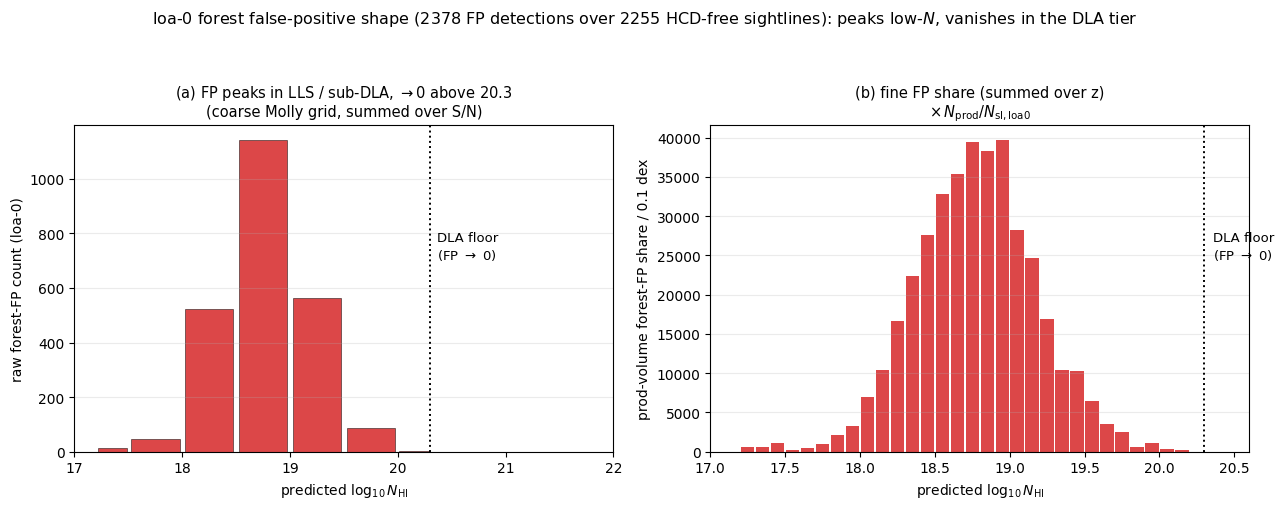


loa-0 FP count, DLA tier (>=20.3) : 0.0
loa-0 FP peak bin                  : logN=18.95  (239 counts)
SELF-CHECK PASS — forest FP is ~0 in the DLA tier (<< the sub-DLA peak).


In [2]:
fp = np.load(tutorial_fixture("loa0_fp_product_lyaonly1025.npz", stage="fp"), allow_pickle=True)
print("FP product keys:", sorted(fp.files))

# coarse Molly-grid FP count (summed over S/N) and the fine 0.1-dex shape
n_fp_molly = fp["n_fp_molly"]              # (8 SNR, 12 logN) raw FP counts
nedg = fp["nhi_edges"]                     # (13,) coarse logN edges (last = inf)
n_fp_fine = fp["n_fp_fine"]                # (52 logN, 3 z) raw FP counts
lo, hi = fp["logN_lo"], fp["logN_hi"]      # fine 0.1-dex edges
n_total = int(fp["n_fp_total"]); n_sl = int(fp["n_sl_loa0"])
vol_scale = float(fp["n_sl_prod"]) / float(fp["n_sl_loa0"])   # N_prod / N_sl_loa0

fp_per_logN = n_fp_molly.sum(axis=0)       # (12,) coarse, summed over S/N
centers = 0.5 * (nedg[:-1] + np.where(np.isfinite(nedg[1:]), nedg[1:],
                                      nedg[:-1] + 0.5))
widths = np.where(np.isfinite(nedg[1:]), nedg[1:] - nedg[:-1], 0.5)
fine = n_fp_fine.sum(axis=1)               # (52,) fine, summed over z
fc = 0.5 * (lo + hi)

# the production-volume per-detection FP SHARE per 0.1 dex: the loa-0 FP count
# extrapolated to the production survey volume (the quantity that feeds lambda_FP).
share_fine = fine * vol_scale

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.0))

# (a) coarse Molly-grid FP count: red below 20.3, blue (->0) above
ax = axes[0]
cols = ["#d62728" if c < 20.3 else "#1f77b4" for c in centers]
ax.bar(centers, fp_per_logN, width=widths * 0.9, color=cols, alpha=0.85,
       align="center", edgecolor="k", lw=0.4)
ax.axvline(20.3, color="black", ls=":", lw=1.4)
ax.text(20.36, 0.62 * fp_per_logN.max(), "DLA floor\n(FP $\\to$ 0)",
        fontsize=9.5, color="black")
ax.set_xlabel(r"predicted $\log_{10} N_{\rm HI}$")
ax.set_ylabel("raw forest-FP count (loa-0)")
ax.set_title("(a) FP peaks in LLS / sub-DLA, $\\to 0$ above 20.3\n"
             "(coarse Molly grid, summed over S/N)", fontsize=10.5)
ax.set_xlim(17.0, 22.0)
ax.grid(alpha=0.25, axis="y")

# (b) fine production-volume FP share per 0.1 dex
ax = axes[1]
g = share_fine > 0
colsf = ["#d62728" if c < 20.3 else "#1f77b4" for c in fc[g]]
ax.bar(fc[g], share_fine[g], width=0.09, color=colsf, alpha=0.85,
       edgecolor="none")
ax.axvline(20.3, color="black", ls=":", lw=1.4)
ax.text(20.36, 0.62 * share_fine[g].max(), "DLA floor\n(FP $\\to$ 0)",
        fontsize=9.5, color="black")
ax.set_xlabel(r"predicted $\log_{10} N_{\rm HI}$")
ax.set_ylabel("prod-volume forest-FP share / 0.1 dex")
ax.set_title("(b) fine FP share (summed over z)\n"
             "$\\times\\, N_{\\rm prod}/N_{\\rm sl,loa0}$", fontsize=10.5)
ax.set_xlim(17.0, 20.6)
ax.grid(alpha=0.25, axis="y")

fig.suptitle(
    f"loa-0 forest false-positive shape ({n_total} FP detections over "
    f"{n_sl} HCD-free sightlines): peaks low-$N$, vanishes in the DLA tier",
    fontsize=11.5, y=1.01)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ---- SELF-CHECK: the FP share in the DLA tier (>=20.3) is ~0 ----
fp_above = float(fine[fc >= 20.3].sum())          # raw loa-0 FP count >=20.3
fp_peak = float(fine.max())                       # the sub-DLA peak bin
peak_logN = float(fc[np.argmax(fine)])
print(f"\nloa-0 FP count, DLA tier (>=20.3) : {fp_above:.1f}")
print(f"loa-0 FP peak bin                  : logN={peak_logN:.2f}  "
      f"({fp_peak:.0f} counts)")
assert fp_above == 0.0 or fp_above < 0.01 * fp_peak, (
    f"FP not negligible in DLA tier: {fp_above} vs peak {fp_peak}")
assert 18.5 <= peak_logN <= 19.1, f"FP peak not in LLS/sub-DLA: {peak_logN}"
print("SELF-CHECK PASS — forest FP is ~0 in the DLA tier "
      "(<< the sub-DLA peak).")

## FP subtraction is a *share*, not a density (the historical units bug)

There were two routes to the FP background, and getting the **units** right is
load-bearing:

- **`purity_mixture` (headline).** $\mu_{\rm FP,cell}=\sum_{i\in{\rm cell}}(1-\rho_i)$,
  where $\rho_i$ is the per-detection purity. Cheap, zero extra compute.

- **`loa0` (non-circular cross-check).** The directly-measured loa-0 forest-FP
  count, rescaled to production volume — the figure above.

The per-detection FP term $\lambda_{{\rm FP},i}$ is a **dimensionless per-object
share** — a *count*, **commensurable with** $\lambda_{{\rm real},i}=\sum_b
A_{i,b}f_b$ (also a per-object expected count, median $\approx 0.35$). The
historical bug fed a **rate density** ($b_{\rm FP}\approx 0.008$, per unit $\hat
N$ per sightline) into that same slot — incommensurable with the per-object count
— which **under-subtracted the FP $\sim 20$–$30\times$** at sub-DLA. The fix
(`Loa0FP`, `FIX 1`) returns $\lambda_{{\rm FP},i}=\mu_{\rm FP,cell}/N_{\rm
cat,cell}\cdot(1-\eta)$: the production-volume FP **count** in the cell, spread
over the catalog detections that landed there.

The two estimators serve different roles — `purity_mixture` is the headline,
`loa0` is the independent cross-check — and in the **DLA tier they agree: both
give $\approx 0$ FP** (cell 4). The disagreement, where it matters, is in the
sub-DLA/LLS regime, which the DLA-tier headline does not depend on.

## The recovered CDDF $f(N)$ and the integrated headline

Now the payoff. Both fits — `purity_mixture` (**headline**) and `loa0`
(**cross-check**) — were run to MAP on the real 2LPT-0 catalog; we load the cached
recovered heights `f_b` and the integrated $dN/dX$ / $\Omega_{\rm HI}$ at the three
report limits $20.0/20.3/20.6$.

> **Which kernel produced this cached fit.** The cached fits loaded here
> (`point_kernel_pm.npz`, `point_kernel_loa0.npz`) use the **$\kappa$
> posterior-kernel** — the *deprecated* 2026-06-19 diagnostic (a $\sim$698k /
> no-SNR-cut / BAL-in selection). The **production forward-response kernel** closes
> this to $R_0\approx0.99$ flat in $z$ — see **NB5 §2b** for that live recovery. The
> $R_0\approx1.09$ shown below is the $\kappa$ **diagnostic**, *not* the shipped
> headline. This notebook teaches the MAP/likelihood/band machinery on the cached
> $\kappa$ fit; the kernel choice does not change that machinery.

We compare the integrated $dN/dX(\ge 20.3)$ to the **2LPT-0 mock truth**
($dN/dX_{\rm truth}=0.05434$, $10^3\Omega_{\rm truth}=0.6288$). The ratio
$R_0=\,$recovered$/$truth measures the pre-$\alpha$ recovery (see the honesty cell
on why this is *not* a circular $\alpha=1/R_0$ claim).

> **$\Omega$ integration ceiling.** $\Omega(\ge 20.3)=\int N f(N)\,dN$ is integrated
> only up to the $f(N)$ fit's high-$N$ edge ($\log N\!\approx\!22.0$–$22.5$), not the
> literature $10^{23}$ upper limit. The truncated fraction is model-dependent: up to $\sim$18% for a moderate ($\beta\!\approx\!2.3$) power-law tail extrapolated to $10^{23}$, but far smaller (near zero) if $f(N)$ steepens / cuts off at high $N$ as the data favour. This
> is part of why the tutorial's $\Omega(\ge 20.3)\approx 6.5\times10^{-4}$ sits
> $\sim$11% below Ho+2021's $7.3\times10^{-4}$ (the rest is FP/kernel and deep-tail
> systematics; the full budget is quantified in NB4).

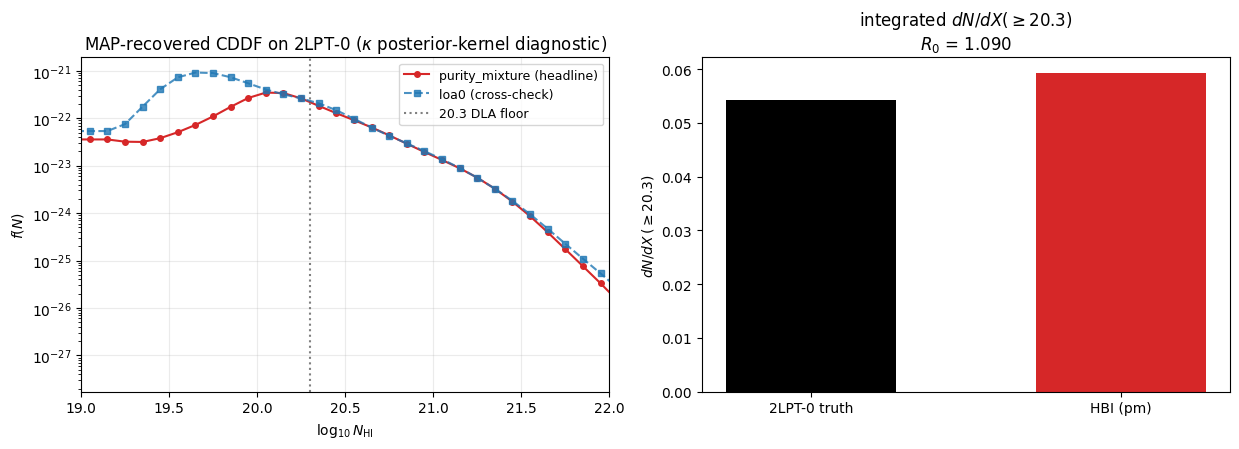

 limit    dN/dX (pm)   dN/dX (loa0)   1e3*Omega (pm)  1e3*Omega (loa0)
  20.0       0.09010        0.09459           0.7087            0.7634
  20.3       0.05924        0.06298           0.6469            0.7007
  20.6       0.03403        0.03468           0.5491            0.5915

pm dN/dX(>=20.3)   : 0.05924   (expected ~0.05924)
2LPT-0 truth       : 0.05434
R0 (dN/dX)         : 1.090   (~1.09, kappa posterior-kernel DIAGNOSTIC)
R0 (Omega)         : 1.029   (~1.03, kappa diagnostic)
SELF-CHECK PASS — cached kappa posterior-kernel fit recovers 2LPT-0 dN/dX(>=20.3) to ~9% (pre-alpha DIAGNOSTIC; the production forward-response
                  kernel closes this to R0~0.99 flat in z -- see NB5 section 2b).


In [3]:
pm = np.load(tutorial_fixture("point_kernel_pm.npz"))     # HEADLINE purity_mixture fit
l0 = np.load(tutorial_fixture("point_kernel_loa0.npz"))   # loa0 cross-check fit

lo_pm, hi_pm = pm["logN_lo"], pm["logN_hi"]
ctr = 0.5 * (lo_pm + hi_pm)

# --- the recovered f(N) curves -------------------------------------------------
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12.5, 4.6))

m_pm = pm["f_b"] > 0
m_l0 = l0["f_b"] > 0
axL.plot(ctr[m_pm], pm["f_b"][m_pm], "o-", ms=4, color="tab:red",
         label="purity_mixture (headline)")
axL.plot(ctr[m_l0], l0["f_b"][m_l0], "s--", ms=4, color="tab:blue",
         alpha=0.8, label="loa0 (cross-check)")
axL.axvline(20.3, ls=":", color="gray", label="20.3 DLA floor")
axL.set_yscale("log")
axL.set_xlim(19.0, 22.0)
axL.set_xlabel(r"$\log_{10} N_{\rm HI}$")
axL.set_ylabel(r"$f(N)$")
axL.set_title("MAP-recovered CDDF on 2LPT-0 ($\\kappa$ posterior-kernel diagnostic)")
axL.legend(fontsize=9)
axL.grid(alpha=0.25)

# --- integrated headline: dN/dX(>=20.3) recovered vs truth ---------------------
truth_dndx = 0.05434
truth_1e3omega = 0.6288
pm_dndx = float(pm["dndx_total_20.3"])
pm_omega = float(pm["omega_20.3"])
axR.bar([0, 1], [truth_dndx, pm_dndx], color=["k", "tab:red"], width=0.55)
axR.set_xticks([0, 1]); axR.set_xticklabels(["2LPT-0 truth", "HBI (pm)"])
axR.set_ylabel(r"$dN/dX\,(\geq 20.3)$")
axR.set_title(f"integrated $dN/dX(\\geq 20.3)$\n"
              f"$R_0$ = {pm_dndx/truth_dndx:.3f}")
fig.tight_layout()
plt.show()

# --- print the integrated table at all three report limits ---------------------
print(f"{'limit':>6}  {'dN/dX (pm)':>12}  {'dN/dX (loa0)':>13}  "
      f"{'1e3*Omega (pm)':>15}  {'1e3*Omega (loa0)':>16}")
for lim in ("20.0", "20.3", "20.6"):
    print(f"{lim:>6}  {float(pm['dndx_total_'+lim]):>12.5f}  "
          f"{float(l0['dndx_total_'+lim]):>13.5f}  "
          f"{1e3*float(pm['omega_'+lim]):>15.4f}  "
          f"{1e3*float(l0['omega_'+lim]):>16.4f}")

# ---- SELF-CHECK: headline pm dN/dX(>=20.3) and R0 vs 2LPT-0 truth ----
R0_dndx = pm_dndx / truth_dndx
R0_omega = (1e3 * pm_omega) / truth_1e3omega
assert abs(pm_dndx - 0.05924) < 1e-3, f"pm dndx_20.3 drifted: {pm_dndx}"
print(f"\npm dN/dX(>=20.3)   : {pm_dndx:.5f}   (expected ~0.05924)")
print(f"2LPT-0 truth       : {truth_dndx:.5f}")
print(f"R0 (dN/dX)         : {R0_dndx:.3f}   (~1.09, kappa posterior-kernel DIAGNOSTIC)")
print(f"R0 (Omega)         : {R0_omega:.3f}   (~1.03, kappa diagnostic)")
print("SELF-CHECK PASS — cached kappa posterior-kernel fit recovers 2LPT-0 "
      "dN/dX(>=20.3) to ~9% (pre-alpha DIAGNOSTIC; the production forward-response")
print("                  kernel closes this to R0~0.99 flat in z -- see NB5 section 2b).")

## How the MAP fit is computed (and why we load it instead of running it)

The recovered heights above are the **maximum-a-posteriori** point of the
likelihood in cell 3. The machinery (`H.v3x_fit_map` / `H._solve_one_lambda`):

- **Smooth, regularized neg-log-posterior.** The objective is
  $-\log L$ plus a curvature penalty $\lambda_{\rm smooth}\lVert D_2\,
  \log_{10}f\rVert^2$ — a B-spline smoothness prior (`bspbody` family) on the CDDF
  shape that tames the ill-conditioned deconvolution tail without biasing the
  integral.
- **Analytic gradient.** $\partial(-\log L)/\partial f_b = M_b - (A^\top
  (w/\lambda_{\rm tot}))_b$, supplied to L-BFGS-B (`jac=True`) — no finite
  differencing, so the solve is fast and exact.
- **Multi-start L-BFGS-B.** Several jittered restarts plus a literature-anchored
  start guard against local minima (`v3x_fit_map`, `n_restart`); the best
  $-\log P$ wins.
- **Per-bin rescaling (conditioning, load-bearing).** $f_b$ spans $\sim 10^{-22}$
  (DLA) to $\sim 10^{-24}$ (high-$N$), with gradients $\sim 10^{23}$. The solver
  optimizes the **dimensionless** $u_b = f_b/f_{{\rm scale},b}$ so every variable
  is $O(1)$; a single global scale drove the small high-$N$ bins to the bound and
  collapsed the tail (see the `_solve_one_lambda` docstring).

**Why this notebook loads, not runs.** The *real* fit assembles $A$ from the
**1.7 GB forward kernel** (built in NB2 from 1150 per-healpix processed-h5
files). That is a SLURM-scale job. The headline + cross-check fits we just
plotted are its cached outputs (`point_kernel_pm.npz`, `point_kernel_loa0.npz`).
To reproduce them from scratch, run **stage 2** of the production driver (see
`CDDF_analysis/hbi/QUICKSTART.md`):

```bash
python CDDF_analysis/hbi/run_phase3d_postkernel.py \
    --stage 2 \
    --out "${OUT}" \
    --catalog-dir "${CAT}" \
    --truth   /nfs/turbo/.../hcd_truth_cat.fits \
    --molly-tsv /scratch/.../molly_matrix.tsv \
    --zbins "2.0,2.5,3.0,3.5" \
    --report-limits "20.0,20.3,20.6" \
    --fit-floor 19.5 --lambda-bspbody 30.0 \
    --n-mc 200 --seed 0 --n-jobs 16
# (stage 1 builds the 1.7 GB kernel cache first; stage 2 is the ~10-min MAP fit.)
```

> Want to *watch the solver run*? **NB1** drives the very same production solver
> `H._solve_one_lambda` on a small synthetic problem — it finishes in seconds and
> recovers an injected truth. This notebook is the real-data, load-and-reduce
> counterpart.

## Running the HBI estimator in production

**NB1 ran the estimator live on synthetic data; here is how the *same machinery*
is invoked on a real production catalog.** Everything above — the marked-Poisson
likelihood, the forward kernel $A$, the MAP deconvolution, the MC band — is driven
by **two production CLIs** that wrap the exact same `cddf_catalog_hbi` functions.
This section is the operator's guide: the inputs, the commands, the module API,
and the outputs (which are the very fixtures this notebook loads).

### Inputs a production run needs

A run starts from a **frozen GP-DLA catalog** (the GP inference is already done —
HBI is *analysis-side only* and never re-runs `dla_gp.py`). It needs:

| input | what it is | flag |
|---|---|---|
| **Frozen catalog dir** | the combined FILTER-on, `MAX_DLAS=4` GP-DLA catalog (the detections + per-object $\hat N$, $\sigma$, $z$, $P_{\rm DLA}$, S/N) | `--catalog-dir` |
| **Truth catalog (FITS)** | mock injected-HCD truth (`hcd_truth_cat.fits`) — used to build the kernel + completeness; **mock only** | `--truth` |
| **BAL catalog (FITS)** | the BAL veto list (`bal_cat.fits`); BAL QSOs are **excluded** (`no_bal=True`, hardcoded in both drivers — no per-driver override). `--keep-bal` exists only on the `python -m CDDF_analysis.hbi.cddf_catalog_hbi` module CLI, not on the drivers | `--bal-cat` |
| **Molly P/C matrix (`.tsv`)** | per-(S/N, $\log N$) purity $\rho$ and completeness $C$ (`molly_matrix.tsv`) — builds $M_b$ and the `purity_mixture` FP | `--molly-tsv` |
| **loa-0 FP product (`.npz`)** | the directly-measured forest-FP per-detection share (cell 4) — **only for the `loa0` cross-check** | `--fp-product` |
| **processed-h5 glob + PW samples** | per-healpix posteriors + QMC grid — **only the SIR-kernel build (`stage1`)** reads these (the R_emp path does not) | `--processed-glob`, `--pw-samples` |

The two production drivers and their SLURM wrappers:

| driver | builds | SLURM wrapper |
|---|---|---|
| `run_remp_kernel.py` | the **empirical truth-match response** kernel $R_{\rm emp}$ (lighter, truth-only; recommended for cross-mock) | `slurm/greatlakes/production/remp_kernel.sbatch` |
| `run_phase3d_postkernel.py` | the **2-D SIR posterior kernel** from the per-healpix posteriors (heavier, the full pipeline) | `slurm/greatlakes/production/phase3d_postkernel.sbatch` |

### The CLI — stage 1: build the forward kernel

The kernel build is the heavy step (the 1.7 GB cache; ~3–5 h for the SIR kernel
over 1150 processed-h5, ~20 min for $R_{\rm emp}$). Submit it via SLURM:

```bash
# GreatLakes: -A cavestru1 -p standard -N 1 -n 16 --mem 64G, BLAS pinned to 1
sbatch slurm/greatlakes/production/remp_kernel.sbatch
```

…or run a single stage interactively from the repo root:

```bash
python CDDF_analysis/hbi/run_remp_kernel.py \
    --stage build \                  # build (+cache) the R_emp kernel only
    --out       "${OUT}" \           # output dir (kernel cache + npz + figures land here)
    --catalog-dir "${CAT}" \         # frozen GP-DLA combined catalog
    --truth     /nfs/turbo/.../hcd_truth_cat.fits \
    --bal-cat   /nfs/turbo/.../bal_cat.fits \
    --molly-tsv /scratch/.../molly_matrix.tsv \
    --zbins         "2.0,2.5,3.0,3.5" \   # coarse z report bins
    --report-limits "20.0,20.3,20.6" \    # integrated dN/dX & Omega thresholds
    --lam-rf-min 911.0 \             # 911=Lya+Lyb search window (1025.7=Lya-only)
    --n-jobs 16                      # file-parallel workers (BLAS pinned to 1 each)
```

### The CLI — stage 2: the MAP fit (+ band)

With the kernel cached, the MAP fit is the ~10-min step. `--stage 2` runs the
bspbody MAP fit; `--stage all` runs build → fit → WALL-1 tilt closure in sequence:

```bash
python CDDF_analysis/hbi/run_phase3d_postkernel.py \
    --stage 2 \                      # MAP fit only (needs the stage-1 kernel cache)
    --out       "${OUT}" \
    --catalog-dir "${CAT}" \
    --truth     /nfs/turbo/.../hcd_truth_cat.fits \
    --molly-tsv /scratch/.../molly_matrix.tsv \
    --fit-floor 19.5 \               # detection-row logN floor for the deconvolution
    --lambda-bspbody 30.0 \          # B-spline 2nd-diff curvature penalty (smoothness)
    --fp-estimator purity_mixture \  # HEADLINE FP model (loa0 = non-circular cross-check)
    --report-limits "20.0,20.3,20.6" \
    --mc-nuisance shared_boot \      # correlated band: one shared TID-blocked resample/draw
    --n-mc 200 \                     # MC draws for the band (>=240 for publication)
    --seed 0 --n-jobs 16
```

One-line meaning of the load-bearing flags:

| flag | meaning |
|---|---|
| `--fit-floor 19.5` | rows below this $\log N$ are out-of-band for the deconvolution (the LLS/sub-DLA floor) |
| `--lambda-bspbody 30.0` | strength of the B-spline curvature penalty — tames the deconvolution tail without biasing the integral |
| `--fp-estimator` | `purity_mixture` (headline, $(1-\rho)$ per row) or `loa0` (the non-circular forest-FP product; needs `--fp-product`) |
| `--report-limits` | the $\log N$ thresholds at which $dN/dX$ and $\Omega$ are integrated and reported |
| `--zbins` | coarse-$z$ report edges for the per-$z$ differential CDDF |
| `--mc-nuisance` | `indep` (per-cell independent draws) or `shared_boot` (one shared TID-blocked resample → $C$, $\rho$ correlated) — the UQ knob of cell 8 |
| `--n-mc` | number of correlated-MC draws for the statistical band |
| `--report-limits …,20.6` | $\ge 20.6$ **must** be a report limit or the frozen WALL-1 gate contract is not evaluated |

> The R_emp driver (`run_remp_kernel.py`) takes the same flags plus `--dalpha`
> (WALL-1 tilt magnitude) and `--smooth-bins`/`--n-floor` (the truth-match
> response smoothing). The two drivers differ in their `--stage` vocabulary:
> `run_remp_kernel.py` uses `--stage {build,2,3,all}` (the kernel build is
> `build`), whereas `run_phase3d_postkernel.py` uses
> `--stage {1,2,3,all,s3_prior_null,s3_dense_synthetic,s3_all}` (the kernel build
> is stage **`1`**, not `build`).

### The module API: `HBIConfig` and the estimator entry points

Under the CLI, a run is one `HBIConfig` dataclass threaded through the estimator
functions. Below we build a config exactly as `run_phase3d_postkernel._make_cfg`
does (dummy paths — we instantiate it, we do **not** run it) and print the knobs
that matter. **Two defaults to flag:** the headline production run sets
`resp_kind="forward"` and `v3_family="bspbody"`, but the dataclass **defaults** are
the *legacy* `resp_kind="kappa"` and `v3_family="plaw"` — the production driver
overrides them. The FP default `fp_estimator="purity_mixture"` **is** the
headline.

In [4]:
# Instantiate HBIConfig the way run_phase3d_postkernel._make_cfg does.
# Paths are placeholders — we build + inspect the config, we do NOT run a fit here.
cfg = H.HBIConfig(
    catalog_dir="<FROZEN_GP_DLA_CATALOG_DIR>",
    truth_path="<hcd_truth_cat.fits>",
    bal_cat_path="<bal_cat.fits>",
    molly_tsv="<molly_matrix.tsv>",
    out_dir="<OUT>",
    zbins=(2.0, 2.5, 3.0, 3.5),
    report_logN_limits=(20.0, 20.3, 20.6),
    fp_estimator="purity_mixture",   # HEADLINE FP (default); 'loa0' = cross-check
    v3_family="bspbody",             # production override (dataclass default = 'plaw')
    v3_logN_fit_floor=19.5,
    v3_lambda_bspbody=30.0,
    mc_nuisance="shared_boot",       # correlated band (cell 8); default 'indep'
    n_mc=200, rng_seed=0,
)
print("HBIConfig — the production knobs")
print(f"  catalog cuts     : SNR > {cfg.snr_min}, P_DLA > {cfg.p_dla_min}, "
      f"z in [{cfg.z_qso_min}, {cfg.z_qso_max}]")
print(f"  fine logN grid   : [{cfg.logN_lo}, {cfg.logN_hi}] step {cfg.dlogN}")
print(f"  report limits    : {cfg.report_logN_limits}")
print(f"  fp_estimator     : {cfg.fp_estimator!r}   (headline)")
print(f"  v3_family        : {cfg.v3_family!r}      (production; dataclass default 'plaw')")
print(f"  resp_kind        : {cfg.resp_kind!r}      "
      f"(dataclass DEFAULT is legacy 'kappa'; headline run sets 'forward')")
print(f"  fit floor / lam  : {cfg.v3_logN_fit_floor} / {cfg.v3_lambda_bspbody}")
print(f"  mc_nuisance/n_mc : {cfg.mc_nuisance!r} / {cfg.n_mc}")

# ---- the estimator entry points this config flows through ----
print("\nEstimator entry points (in CDDF_analysis/hbi/cddf_catalog_hbi.py):")
for fn, what in (
    ("build_A_ib",
     "per-object forward response A_{i,b}: spreads each true N-bin onto "
     "detection i via the (kernel x C x dX/dz) measurement model -> lambda_real = A.f"),
    ("build_M_b",
     "the path-length normalizer M_b = dN_b * sum_s C_{s,b} dX_s -> mu_det = M.f "
     "(the -mu Poisson 'you only see what you searched' penalty)"),
    ("v3x_fit_map",
     "the MAP solve: multi-start L-BFGS-B on the smoothed neg-log-posterior "
     "(analytic gradient, literature-anchored start) -> theta_MAP"),
    ("v3x_reduce",
     "reduce f(N|theta_MAP) -> integrated dN/dX and Omega_HI at each report limit "
     "(+ per-z differential CDDF, recovered slope)"),
):
    ok = hasattr(H, fn)
    print(f"  H.{fn:<14} {'[ok]' if ok else '[MISSING]'}  {what}")
    assert ok, f"entry point {fn} missing from estimator module"

print("\nSELF-CHECK PASS — HBIConfig builds; all four estimator entry points resolve.")

HBIConfig — the production knobs
  catalog cuts     : SNR > 2.0, P_DLA > 0.99, z in [2.0, 4.25]
  fine logN grid   : [17.2, 22.5] step 0.1
  report limits    : (20.0, 20.3, 20.6)
  fp_estimator     : 'purity_mixture'   (headline)
  v3_family        : 'bspbody'      (production; dataclass default 'plaw')
  resp_kind        : 'kappa'      (dataclass DEFAULT is legacy 'kappa'; headline run sets 'forward')
  fit floor / lam  : 19.5 / 30.0
  mc_nuisance/n_mc : 'shared_boot' / 200

Estimator entry points (in CDDF_analysis/hbi/cddf_catalog_hbi.py):
  H.build_A_ib     [ok]  per-object forward response A_{i,b}: spreads each true N-bin onto detection i via the (kernel x C x dX/dz) measurement model -> lambda_real = A.f
  H.build_M_b      [ok]  the path-length normalizer M_b = dN_b * sum_s C_{s,b} dX_s -> mu_det = M.f (the -mu Poisson 'you only see what you searched' penalty)
  H.v3x_fit_map    [ok]  the MAP solve: multi-start L-BFGS-B on the smoothed neg-log-posterior (analytic gradient, literat

### Outputs — and how they connect to *this* notebook

A production run writes its results to `${OUT}/`. The headline artifacts are
exactly the fixtures this notebook loads:

| run output | this notebook loads it as | content |
|---|---|---|
| `phase3d_v3_point_kernel.npz` (pm run) | `point_kernel_pm.npz` (cell 6) | the headline MAP fit: `f_b`, `theta_map`, `dndx_total_*`, `omega_*` |
| `phase3d_v3_point_kernel.npz` (loa0 run) | `point_kernel_loa0.npz` (cell 6) | the `loa0` cross-check MAP fit (same schema) |
| `stage2_band_compare.npz` | `stage2_band_compare.npz` (cell 8) | the correlated-MC band draws (`indep` + `shared_boot`, both estimators) |
| `posterior_kernel_2lpt0.npz` | (the 1.7 GB cache; NB2 reduces its coefficients) | the cached 2-D forward kernel reused across stages |
| `figures/fig_compare_integrated.png` | regenerated as the cell-6 / cell-8 figures | HBI vs raw feed-forward vs truth, $R_0$ annotated |

So the cells above are not a re-implementation — they **load the actual npz a
production stage-2 run emits** and reduce it to the same figures. The only steps
that still require the scratch cache are the from-scratch MAP refit (the 1.7 GB
kernel) and the cross-mock / real-LOA application, which we show as commands.

## Quantifying the uncertainty: the Monte-Carlo band

A point estimate is not a measurement without an uncertainty. **This is where HBI
earns its keep:** it propagates the calibration uncertainty all the way to the
integrated headline. The production pipeline does this by a **correlated
Monte-Carlo** — it resamples the completeness/purity cells and the FP background,
**re-solves the MAP each draw** (the `--mc-nuisance` / `--n-mc` knobs of the CLI
above), and reduces each draw to $dN/dX$ and $\Omega$. The fixture
`stage2_band_compare.npz` holds those draws for **both** estimators
(`pm`, `loa0`), **both** nuisance methods (`indep`, `shared_boot`), and the three
report limits.

The two figures below are the UQ demonstration:

1. **The band itself** (this cell) — for the headline `purity_mixture` fit, the
   integrated $dN/dX$ and $10^3\Omega$ at each report limit: the **MAP point** (the
   central value), the **2LPT-0 truth**, and the correlated-MC band (16th–84th
   percentile of the `shared_boot` draws). Watch the MAP point sit *above* the
   band — a **Jensen-type offset**: the per-draw MAP $\hat\theta(\psi)$ is a
   **non-linear functional of the resampled nuisances** $\psi$, so the MC
   band sits below the plug-in point $\hat\theta(\mathbb{E}[\psi])$. The draws are
   empirically **near-symmetric** (mean $\approx$ median), explained in the honesty
   cell.
2. **`indep` vs `shared_boot`** (next cell) — *how you draw the nuisance matters*:
   correlating the per-cell resamples (`shared_boot`) shifts the band relative to
   pretending each cell is independent (`indep`) — both stay narrow, which is the
   whole point.

band keys (sample): ['pm_indep_dndx_20.3', 'pm_indep_omega_20.3', 'pm_shared_boot_dndx_20.3', 'pm_shared_boot_omega_20.3', 'pm_point_dndx_20.3', 'pm_point_omega_20.3', 'pm_truth_dndx_20.3', 'pm_truth_omega_20.3']


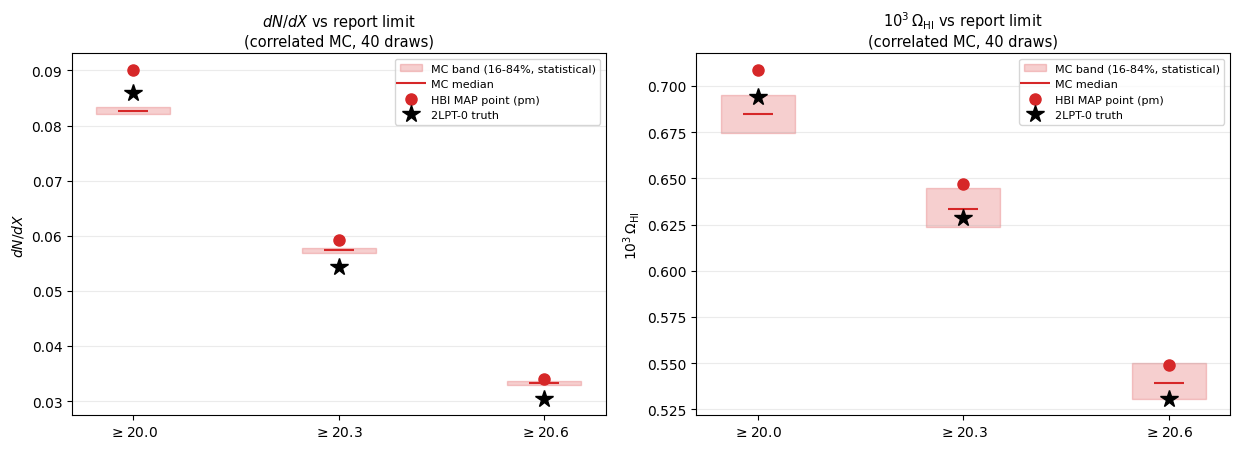

dN/dX(>=20.3) MAP point : 0.05924
  correlated-MC band    : [0.05683, 0.05781]  (16-84%)
  band half-width        : 0.83% of the point
  2LPT-0 truth           : 0.05434

SELF-CHECK PASS — the MAP point sits ABOVE the MC band's 84th pct (Jensen-type offset: non-linear argmax psi->theta_hat; draws near-symmetric; see the honesty cell).


In [5]:
b = np.load(tutorial_fixture("stage2_band_compare.npz"), allow_pickle=True)
print("band keys (sample):",
      [k for k in b.files if k.startswith("pm_") and "20.3" in k])
limits = [float(x) for x in b["report_limits"]]   # [20.0, 20.3, 20.6]
n_mc = int(b["n_mc"])
lim_tags = ["20.0", "20.3", "20.6"]

def _band(prefix, quant, lim):
    '''16/50/84 of the correlated-MC (shared_boot) draws for a given quantity.'''
    draws = b[f"{prefix}_shared_boot_{quant}_{lim}"]
    return np.percentile(draws, [16, 50, 84])

fig, (axA, axB) = plt.subplots(1, 2, figsize=(12.5, 4.6))
x = np.arange(len(lim_tags))

for ax, quant, scale, lbl in (
        (axA, "dndx", 1.0, r"$dN/dX$"),
        (axB, "omega", 1e3, r"$10^3\,\Omega_{\rm HI}$")):
    pts = np.array([scale * float(b[f"pm_point_{quant}_{t}"]) for t in lim_tags])
    tru = np.array([scale * float(b[f"pm_truth_{quant}_{t}"]) for t in lim_tags])
    lo16, med, hi84 = (np.array([_band("pm", quant, t) for t in lim_tags]).T
                       * scale)
    # The MAP point legitimately sits ABOVE the statistical band's 84th pct: this is
    # a JENSEN-TYPE OFFSET. The per-draw MAP theta_hat(psi) is a non-linear
    # functional of the resampled nuisances psi (the positivity-constrained b-spline
    # MAP), so E_psi[theta_hat(psi)] sits below the plug-in point theta_hat(E[psi]).
    # The draws are empirically near-symmetric (mean~median), which licenses the rigid
    # additive median->point recenter. We therefore draw the band as a SPAN around its
    # own median and keep the MAP point as a separate marker (we report the MAP point,
    # not the MC median; the honesty cell explains why).
    for xi, lo_i, hi_i in zip(x, lo16, hi84):
        ax.fill_between([xi - 0.18, xi + 0.18], [lo_i, lo_i], [hi_i, hi_i],
                        color="tab:red", alpha=0.22,
                        label="MC band (16-84%, statistical)"
                        if xi == x[0] else None)
    ax.plot(x, med, "_", color="tab:red", ms=22, mew=1.5, label="MC median")
    ax.plot(x, pts, "o", color="tab:red", ms=8,
            label="HBI MAP point (pm)")
    ax.plot(x, tru, "k*", ms=13, label="2LPT-0 truth")
    ax.set_xticks(x); ax.set_xticklabels([rf"$\geq{t}$" for t in lim_tags])
    ax.set_ylabel(lbl)
    ax.set_title(f"{lbl} vs report limit\n(correlated MC, {n_mc} draws)",
                 fontsize=10.5)
    ax.grid(alpha=0.25, axis="y")
    ax.legend(fontsize=8, loc="best")

fig.tight_layout()
plt.show()

# print the headline number with its statistical band
lo16, med, hi84 = _band("pm", "dndx", "20.3")
pt = float(b["pm_point_dndx_20.3"])
print(f"dN/dX(>=20.3) MAP point : {pt:.5f}")
print(f"  correlated-MC band    : [{lo16:.5f}, {hi84:.5f}]  (16-84%)")
print(f"  band half-width        : {0.5*(hi84-lo16)/pt*100:.2f}% of the point")
print(f"  2LPT-0 truth           : {float(b['pm_truth_dndx_20.3']):.5f}")

# ---- SELF-CHECK: the MAP point sits ABOVE the shared_boot band ----
# (Jensen-type offset: the per-draw MAP theta_hat(psi) is a non-linear
#  functional of the resampled nuisances psi, so E_psi[theta_hat] sits below the
#  plug-in point theta_hat(E[psi]); the draws are near-symmetric, mean~median.)
assert pt > hi84, (f"expected MAP point {pt:.5f} above band 84th pct {hi84:.5f} "
                   "(Jensen-type offset); fixture changed?")
print("\nSELF-CHECK PASS — the MAP point sits ABOVE the MC band's 84th pct "
      "(Jensen-type offset: non-linear argmax psi->theta_hat; draws near-symmetric; "
      "see the honesty cell).")

### Why the *correlation* of the nuisance draw matters: `indep` vs `shared_boot`

How you resample the calibration nuisance changes both the **location** and the
**width** of the band — this is the `--mc-nuisance` knob. Two methods are stored
side-by-side in the fixture:

- **`indep`** — each completeness/purity cell is resampled from its own Jeffreys
  Beta, **independently**.
- **`shared_boot`** — **one** TID-blocked bootstrap resample of the truth-match per
  draw, so $C$, $\rho$, and the bootstrap weights move **coherently** across cells.
  This is the *correct* propagation: the per-cell estimates are not independent —
  they share a common truth-match — so the draws must move together.

The figure contrasts the two for the headline $dN/dX(\ge 20.3)$ and
$10^3\Omega(\ge 20.3)$. The point of the comparison is **not** "one band is wider":
the dominant effect here is a **shift** — the coherent `shared_boot` draws sit
**closer to the MAP point and to truth** than the `indep` draws (whose independent
per-cell scatter biases the reductions low). Either way, both bands are *narrow*
($\sim$1–2% half-width) — the statistical uncertainty is **not** the dominant term
in the budget, which is exactly the point of the honesty cell that follows.

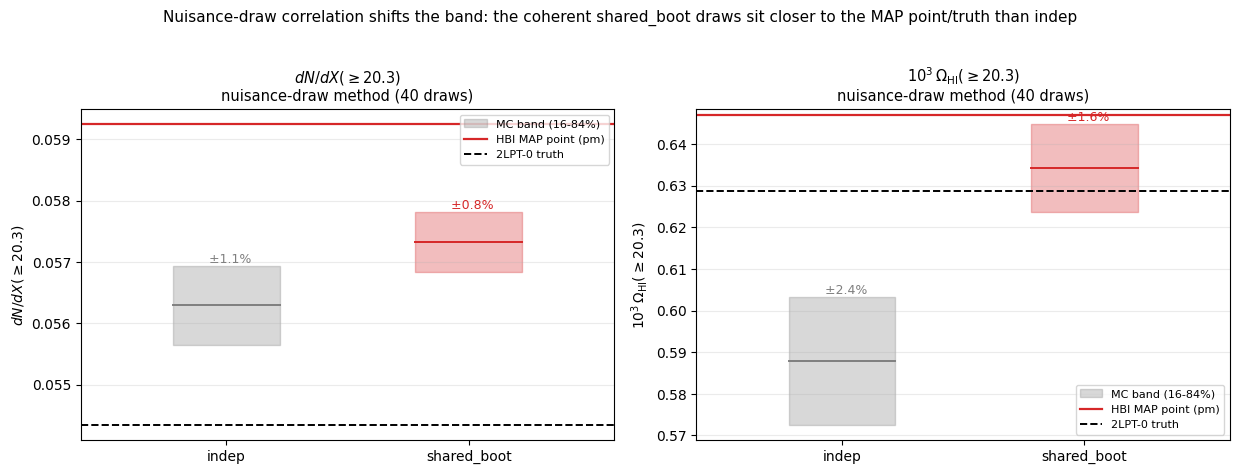

dN/dX(>=20.3) statistical band, by nuisance-draw method (MAP point = 0.05924):
  indep        : [0.05564, 0.05694]  median 0.05636  half-width 1.10% of the point
  shared_boot  : [0.05683, 0.05781]  median 0.05741  half-width 0.83% of the point

SELF-CHECK PASS — both bands are NARROW (indep 1.10% / shared_boot 0.83% half-width) and the coherent shared_boot median sits closer to the MAP point than indep.


In [6]:
def _hw(prefix, method, quant, lim):
    '''half-width (in %) of the 16-84 band for a method, relative to the MAP point.'''
    draws = b[f"{prefix}_{method}_{quant}_{lim}"]
    q16, q84 = np.percentile(draws, [16, 84])
    pt = float(b[f"{prefix}_point_{quant}_{lim}"])
    return q16, q84, pt

fig, (axA, axB) = plt.subplots(1, 2, figsize=(12.5, 4.6))
methods = ["indep", "shared_boot"]
mcol = {"indep": "tab:gray", "shared_boot": "tab:red"}
xm = np.arange(len(methods))

for ax, quant, scale, lbl in (
        (axA, "dndx", 1.0, r"$dN/dX(\geq 20.3)$"),
        (axB, "omega", 1e3, r"$10^3\,\Omega_{\rm HI}(\geq 20.3)$")):
    pt = scale * float(b[f"pm_point_{quant}_20.3"])
    tru = scale * float(b[f"pm_truth_{quant}_20.3"])
    for j, meth in enumerate(methods):
        q16, q84, _ = _hw("pm", meth, quant, "20.3")
        q16 *= scale; q84 *= scale
        ax.fill_between([j - 0.22, j + 0.22], [q16, q16], [q84, q84],
                        color=mcol[meth], alpha=0.30,
                        label="MC band (16-84%)" if j == 0 else None)
        ax.plot([j - 0.22, j + 0.22], [0.5 * (q16 + q84)] * 2, color=mcol[meth],
                lw=1.4)
        ax.text(j, q84, f"  ±{50*(q84-q16)/pt:.1f}%", va="bottom", ha="center",
                fontsize=9, color=mcol[meth])
    ax.axhline(pt, color="tab:red", ls="-", lw=1.6, label="HBI MAP point (pm)")
    ax.axhline(tru, color="k", ls="--", lw=1.4, label="2LPT-0 truth")
    ax.set_xticks(xm); ax.set_xticklabels(methods)
    ax.set_xlim(-0.6, 1.6)
    ax.set_ylabel(lbl)
    ax.set_title(f"{lbl}\nnuisance-draw method ({n_mc} draws)", fontsize=10.5)
    ax.grid(alpha=0.25, axis="y")
    ax.legend(fontsize=8, loc="best")

fig.suptitle("Nuisance-draw correlation shifts the band: the coherent shared_boot "
             "draws sit closer to the MAP point/truth than indep",
             fontsize=11.0, y=1.02)
fig.tight_layout()
plt.show()

# numbers: location + half-width of each method for dN/dX(>=20.3)
pt203 = float(b["pm_point_dndx_20.3"])
print("dN/dX(>=20.3) statistical band, by nuisance-draw method "
      f"(MAP point = {pt203:.5f}):")
for meth in methods:
    q16, q84, _ = _hw("pm", meth, "dndx", "20.3")
    med = float(np.median(b[f"pm_{meth}_dndx_20.3"]))
    print(f"  {meth:<12} : [{q16:.5f}, {q84:.5f}]  median {med:.5f}  "
          f"half-width {50*(q84-q16)/pt203:.2f}% of the point")

# ---- SELF-CHECK: both bands are NARROW; shared_boot sits closer to the MAP point ----
def _hwpct(meth):
    q16, q84, _ = _hw("pm", meth, "dndx", "20.3")
    return 100.0 * 0.5 * (q84 - q16) / pt203
def _gap_to_point(meth):
    return abs(float(np.median(b[f"pm_{meth}_dndx_20.3"])) - pt203)
hw_i, hw_s = _hwpct("indep"), _hwpct("shared_boot")
assert hw_i < 4.0 and hw_s < 4.0, (
    f"a statistical band is unexpectedly wide: indep {hw_i:.2f}% / "
    f"shared_boot {hw_s:.2f}% (expected ~1-2%)")
assert _gap_to_point("shared_boot") < _gap_to_point("indep"), (
    "shared_boot median should sit closer to the MAP point than indep")
print(f"\nSELF-CHECK PASS — both bands are NARROW (indep {hw_i:.2f}% / "
      f"shared_boot {hw_s:.2f}% half-width) and the coherent shared_boot "
      "median sits closer to the MAP point than indep.")

## Honesty: what the band is — and what it is **not**

Read this before quoting the error bar.

**(a) The MC band is statistical only — it is NOT $\sigma_{\rm tot}$.** The band
in cell 8 propagates *sampling* uncertainty (completeness/purity Wilson draws, FP
resampling) and nothing else. The full uncertainty budget is wider:
$$
\sigma_{\rm tot} \approx \pm 8\text{–}9\%\ (dN/dX),
\qquad \pm 12\text{–}16\%\ (\Omega_{\rm HI}),
$$
dominated by completeness/kernel mis-specification, **not** by the narrow
statistical band you just plotted. Quote $\sigma_{\rm tot}$, not the MC band, as
the headline error.

**(b) The high-$N$ kernel bias is a separate, *signed* systematic — do not widen
the band to cover it.** The forward kernel has a one-sided high-$N$
over-recovery (the Eddington amplification at the prior edge). That is a
**directional** systematic with a known sign, not random scatter; it is accounted
for separately in the budget. Inflating the symmetric MC band to "cover" it would
double-count and mis-describe its sign.

**(c) Keep the MAP central value — never report the MC median.** The
MAP-point-above-the-band is a **Jensen-type offset**. Each MC draw resamples the
calibration nuisances $\psi$ (the completeness $C$, purity $\rho$, FP rate, per-object
width) and re-solves the MAP: the per-draw MAP $\hat\theta(\psi)$ is a **non-linear
functional of $\psi$** (the positivity-constrained b-spline argmax), so the
MC band — centered on $\mathbb{E}_\psi[\hat\theta(\psi)]$ — sits **below** the plug-in
point $\hat\theta(\mathbb{E}[\psi])$. (The MAP program is concave in neither $f$ nor $\log f$, so we do *not* invoke a
convex-Jensen inequality; what licenses the rigid additive recenter is the
*measured* near-symmetry of the draws, below.)
Empirically the per-draw distribution is **near-symmetric** (mean $\approx$ median in
every configuration we ran), which is exactly what licenses the rigid additive
median$\to$point recenter (`recenter_band_on_point`): there is no skew to preserve, so
a pure location shift is the correct first-order bias correction. The operational rule:
the band is drawn *around* the MAP point, and we **report the MAP point, not the MC
median**. (In cell 8 the point and the band's median visibly differ for exactly this
reason.)

**(d) $R_0\approx 1.09$ here is the $\kappa$ posterior-kernel *diagnostic*, and a
*pre-$\alpha$* number — not a calibrated claim, and not the shipped headline.** Two
distinct cautions stack here. First, the cached fit above uses the **deprecated
$\kappa$ posterior-kernel** (the 2026-06-19 diagnostic); the production
**forward-response kernel** closes the recovery to $R_0\approx 0.99$ flat in $z$
(**NB5 §2b**). Second, even for the shipped kernel, on a single mock, fitting the
completeness/kernel on the same truth used to *score* the recovery would drive
$R_0\to 1$ by construction (an $\alpha=1/R_0$ tautology); the honest number is the
**pre-$\alpha$** $R_0$. So treat the $\approx 1.09$ ($dN/dX$) / $\approx 1.03$
($\Omega$) here as the $\kappa$-kernel *diagnostic*, not the production headline. The
genuine external test — build the kernel on one mock, apply it to a held-out mock of
a *different* recipe, check $R_0(z)\approx 1$ *without* refitting — is **NB4**.

## Recap and where to go next

We took a measurement kernel into the **rate-form marked-Poisson likelihood**
($\log L = -(\mu_{\rm det}+\mu_{\rm FP}) + \sum_i w_i\log(\lambda_{{\rm
real},i}+\lambda_{{\rm FP},i})$), measured the forest-FP background directly from the
loa-0 twin (peaks at sub-DLA, $\approx 0$ in the DLA tier), ran the **MAP
deconvolution** (loaded from cache; the live solver is in NB1), and put a
**correlated-MC statistical band** on the integrated $dN/dX$ and $\Omega_{\rm HI}$.
The cached fit reduced here uses the **$\kappa$ posterior-kernel diagnostic**, which
on the 2LPT-0 mock gives $dN/dX(\ge 20.3)=0.0592$ ($R_0\approx 1.09$), with `loa0` as
a consistent non-circular cross-check. The **shipped production estimator** swaps in
the **forward-response kernel** (NB2), which closes this to $R_0\approx 0.99$ flat in
$z$ — the live recovery is in **NB5 §2b**.

We were careful about three things: the FP term is a **per-detection share**
(commensurable with $\lambda_{\rm real}$), the MC band is **statistical only**
(not $\sigma_{\rm tot}$), and $R_0\approx 1.09$ is the **pre-$\alpha$** $\kappa$
**diagnostic**, not a calibrated tautology or the production headline.

**Next — NB4 (validation):** the external tests that turn "pre-$\alpha$ recovery"
into a defensible measurement —
- **$R_0$** across the full $N$/$z$ plane;
- the **null-field** test (FP subtraction leaves a no-absorber field flat);
- **simulation-based calibration (SBC)** of the posterior coverage;
- **cross-mock transfer** (kernel built on one mock, applied to a held-out mock of
  a different recipe — *no refit*), and the $\alpha=1/R_0$ honesty that goes with
  it.